In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# All sklearn libraries
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [137]:
import warnings
warnings.filterwarnings('ignore')

In [138]:
df=pd.read_csv("loan_approval_data.csv")

In [139]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [140]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [142]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Missing value Imputation

In [143]:
num_cols=df.select_dtypes("number").columns
cat_cols=df.select_dtypes("object").columns

In [144]:
num_imp=SimpleImputer(strategy="mean")

df[num_cols]=num_imp.fit_transform(df[num_cols])

cat_imp=SimpleImputer(strategy="most_frequent")

df[cat_cols]=cat_imp.fit_transform(df[cat_cols])

In [145]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

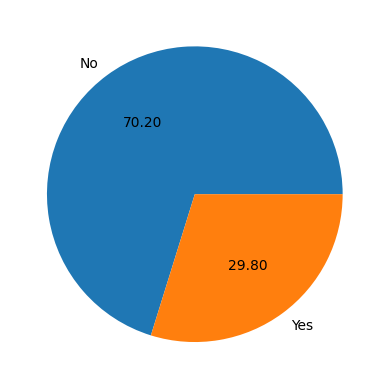

In [146]:
num_counts=df["Loan_Approved"].value_counts()
plt.pie(num_counts,labels=("No","Yes"),autopct='%.2f')
plt.show()

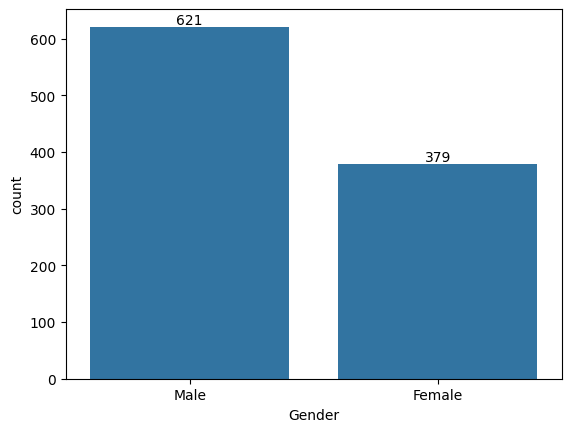

In [147]:
num_counts1=df["Gender"].value_counts()
ax=sns.barplot(num_counts1)
ax.bar_label(ax.containers[0])
plt.show()

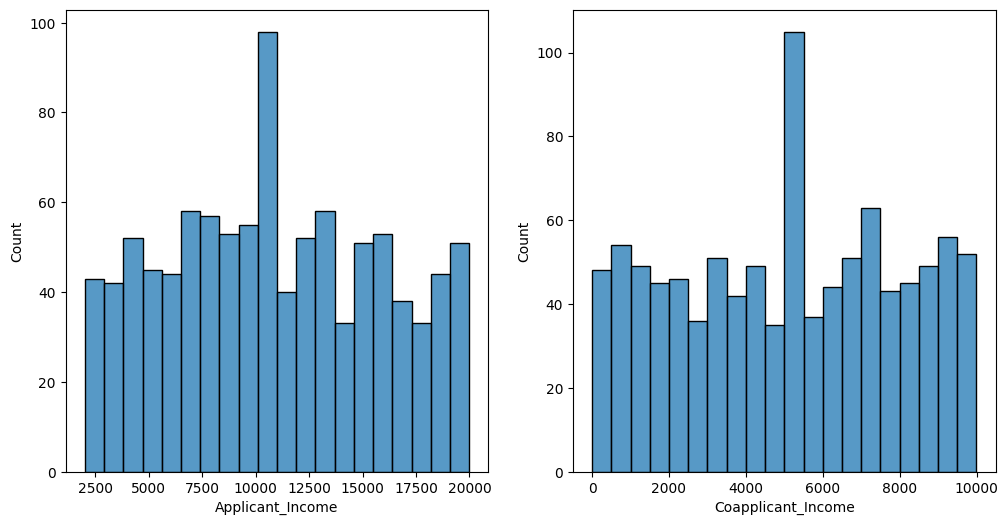

In [148]:
fig,axes=plt.subplots(1,2,figsize=(12,6))
sns.histplot(ax=axes[0],data=df,x="Applicant_Income",bins=20)
sns.histplot(ax=axes[1],data=df,x="Coapplicant_Income",bins=20)
plt.show()

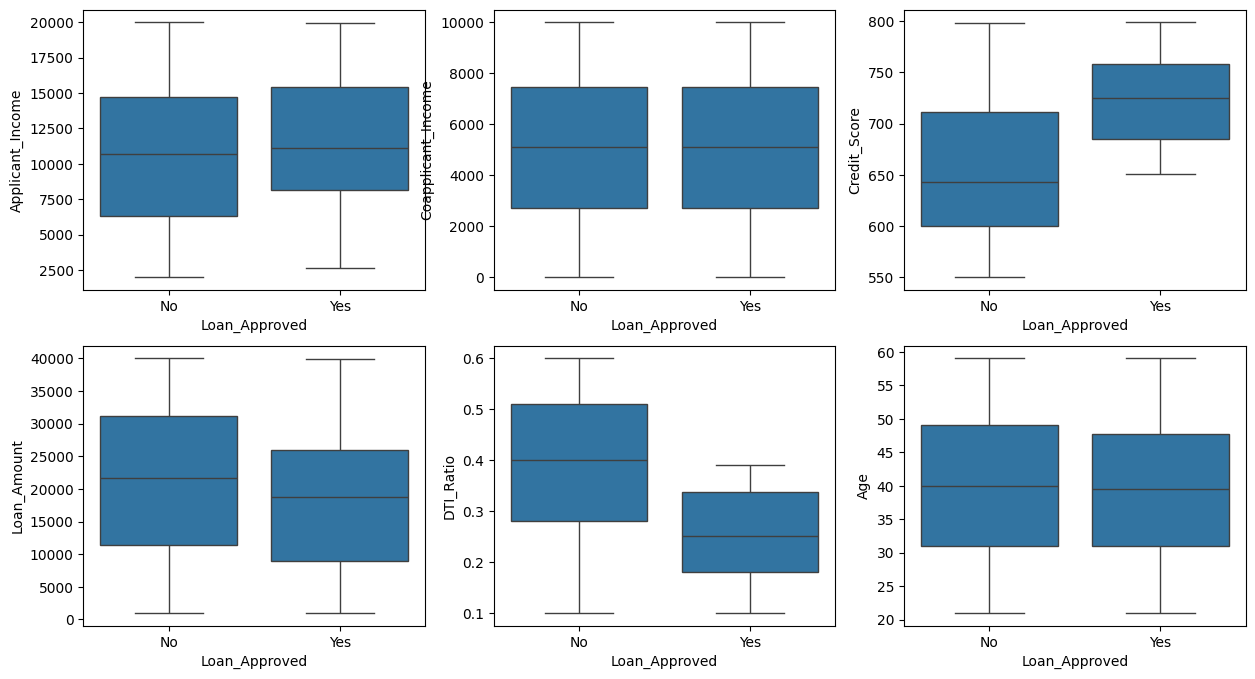

In [149]:
fig, axes=plt.subplots(2,3,figsize=(15,8))

sns.boxplot(ax=axes[0,0],data=df, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df, x="Loan_Approved", y="Coapplicant_Income")
sns.boxplot(ax=axes[0,2],data=df, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df, x="Loan_Approved", y="Loan_Amount")
sns.boxplot(ax=axes[1,1],data=df, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,2],data=df, x="Loan_Approved", y="Age")

plt.show()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

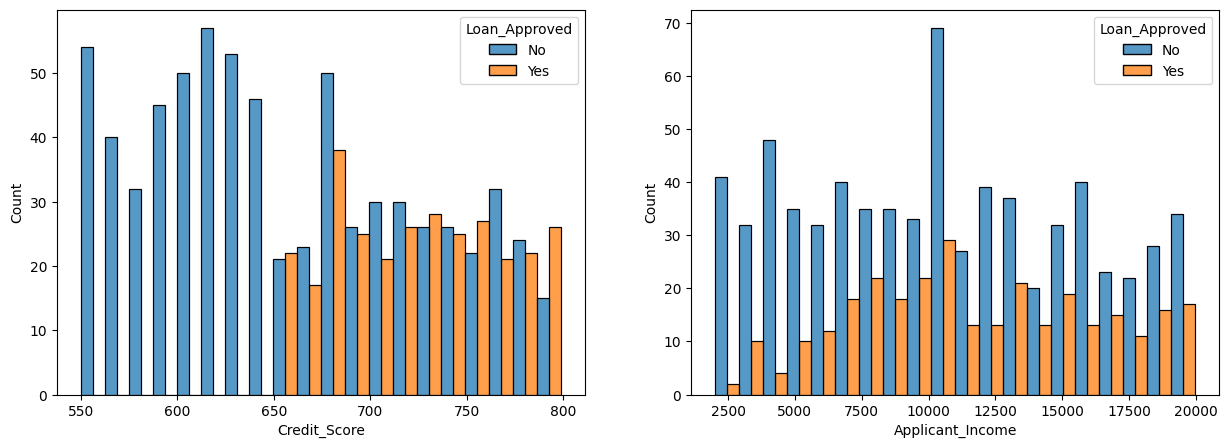

In [150]:
fig, axes=plt.subplots(1,2,figsize=(15,5))

sns.histplot(ax=axes[0],data=df, x="Credit_Score", hue="Loan_Approved",bins=20,multiple="dodge")
sns.histplot(ax=axes[1],data=df, x="Applicant_Income", hue="Loan_Approved",bins=20,multiple="dodge")

# Pre-processing

# Encoding

In [151]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [152]:
df[["Education_Level","Loan_Approved"]]

,Education_Level,Loan_Approved
0,1,0
1,0,0
2,0,1
3,0,0
4,0,1
...,...,...
995,1,0
996,0,0
997,0,0
998,0,1


In [153]:
from sklearn.preprocessing import OneHotEncoder

cat_features=["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe=OneHotEncoder(drop="first",sparse_output=False, handle_unknown="ignore")

encoded=ohe.fit_transform(df[cat_features])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cat_features),index=df.index)

df=pd.concat([df.drop(columns=cat_features),encoded_df],axis=1)

In [154]:
df.head(1)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


# Co-relation heatmap

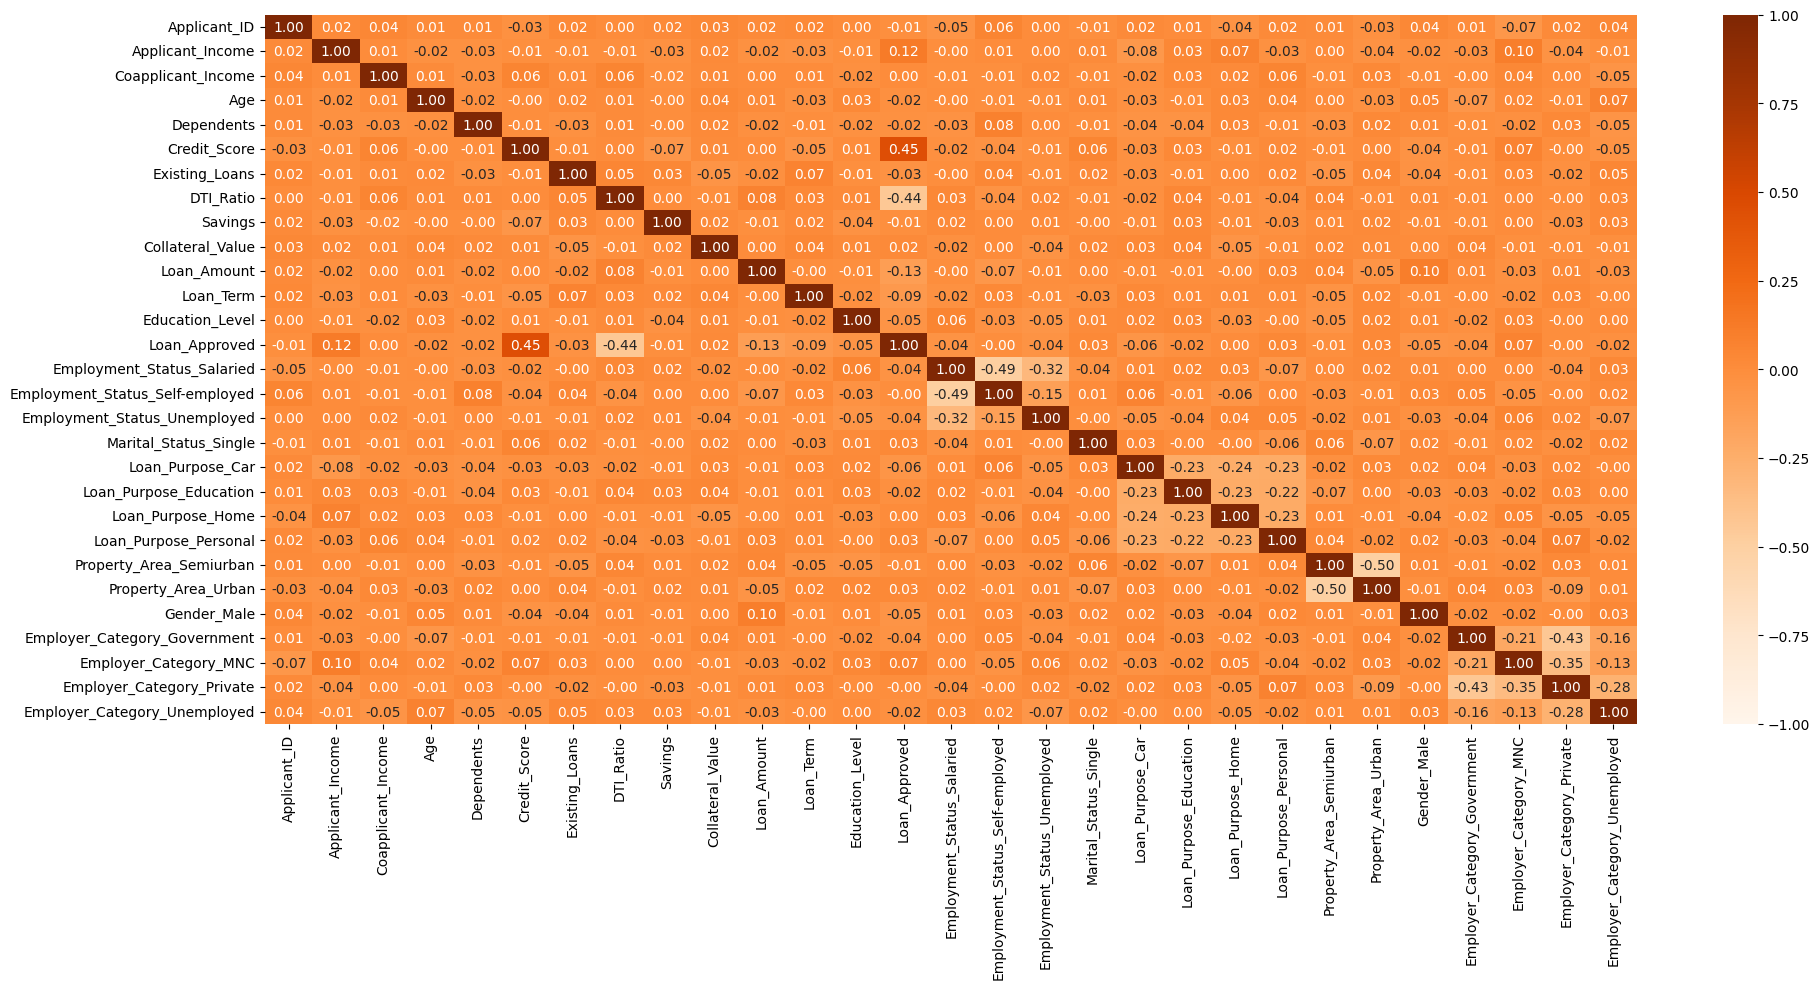

In [155]:
numerical_cols=df.select_dtypes("number")
corelation_matrix = numerical_cols.corr()

plt.figure(figsize=(20,10))
sns.heatmap(
    corelation_matrix,
    vmin=-1, 
    vmax=1, 
    cmap="Oranges",
    annot=True, 
    fmt=".2f"
)

plt.tight_layout()
plt.show()


# Train-Test split

In [156]:
X=df.drop(["Loan_Approved"],axis=1)
y=df["Loan_Approved"]

# Baseline Model Building

In [157]:
# Logistic Regression

LR_model=LogisticRegression()
LR_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [158]:
# Naive Bayes

NB_model=GaussianNB()
NB_model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [159]:
KNN_model=KNeighborsClassifier()
KNN_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [160]:
# Decision Tree

DT_model=DecisionTreeClassifier()
DT_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# Baseline Model Evaluation

In [161]:
results=[]

models={
    "Logistic Regression": LR_model,
    "Naive Bayes": NB_model,
    "KNN":KNN_model,
    "Decision Tree": DT_model
}

for name,model in models.items():
    y_pred=model.predict(X_test)
    
    acc=accuracy_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    pre=precision_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    
    results.append({
        "Model":name,
        "Accuracy":acc,
        "Recall":rec,
        "Precision": pre,
        "F1 score":f1,
            })
    
    print(f"\n{name}")
    print(f"Accuracy: {acc:.2f} | Precision: {pre:.2f} | Recall: {rec:.2f} | F1 score: {f1:.2f}")
    
    print("\n")
    print(f"{name}")
    print("Classification Report:\n",classification_report(y_test,y_pred)),
    print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

results_df = pd.DataFrame(results).set_index("Model").round(2)
print(results_df)

best_model_name = results_df["F1 score"].idxmax()
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name}")



Logistic Regression
Accuracy: 0.69 | Precision: 0.58 | Recall: 0.14 | F1 score: 0.22


Logistic Regression
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.95      0.81       217
           1       0.58      0.14      0.22       103

    accuracy                           0.69       320
   macro avg       0.64      0.54      0.51       320
weighted avg       0.66      0.69      0.62       320

Confusion Matrix:
 [[207  10]
 [ 89  14]]

Naive Bayes
Accuracy: 0.73 | Precision: 0.60 | Recall: 0.49 | F1 score: 0.54


Naive Bayes
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.85      0.81       217
           1       0.60      0.49      0.54       103

    accuracy                           0.73       320
   macro avg       0.69      0.67      0.67       320
weighted avg       0.72      0.73      0.72       320

Confusion Matrix:
 [[184  33]
 [ 53  50]]

KNN
Accuracy:

# Plotting the Decsion Tree

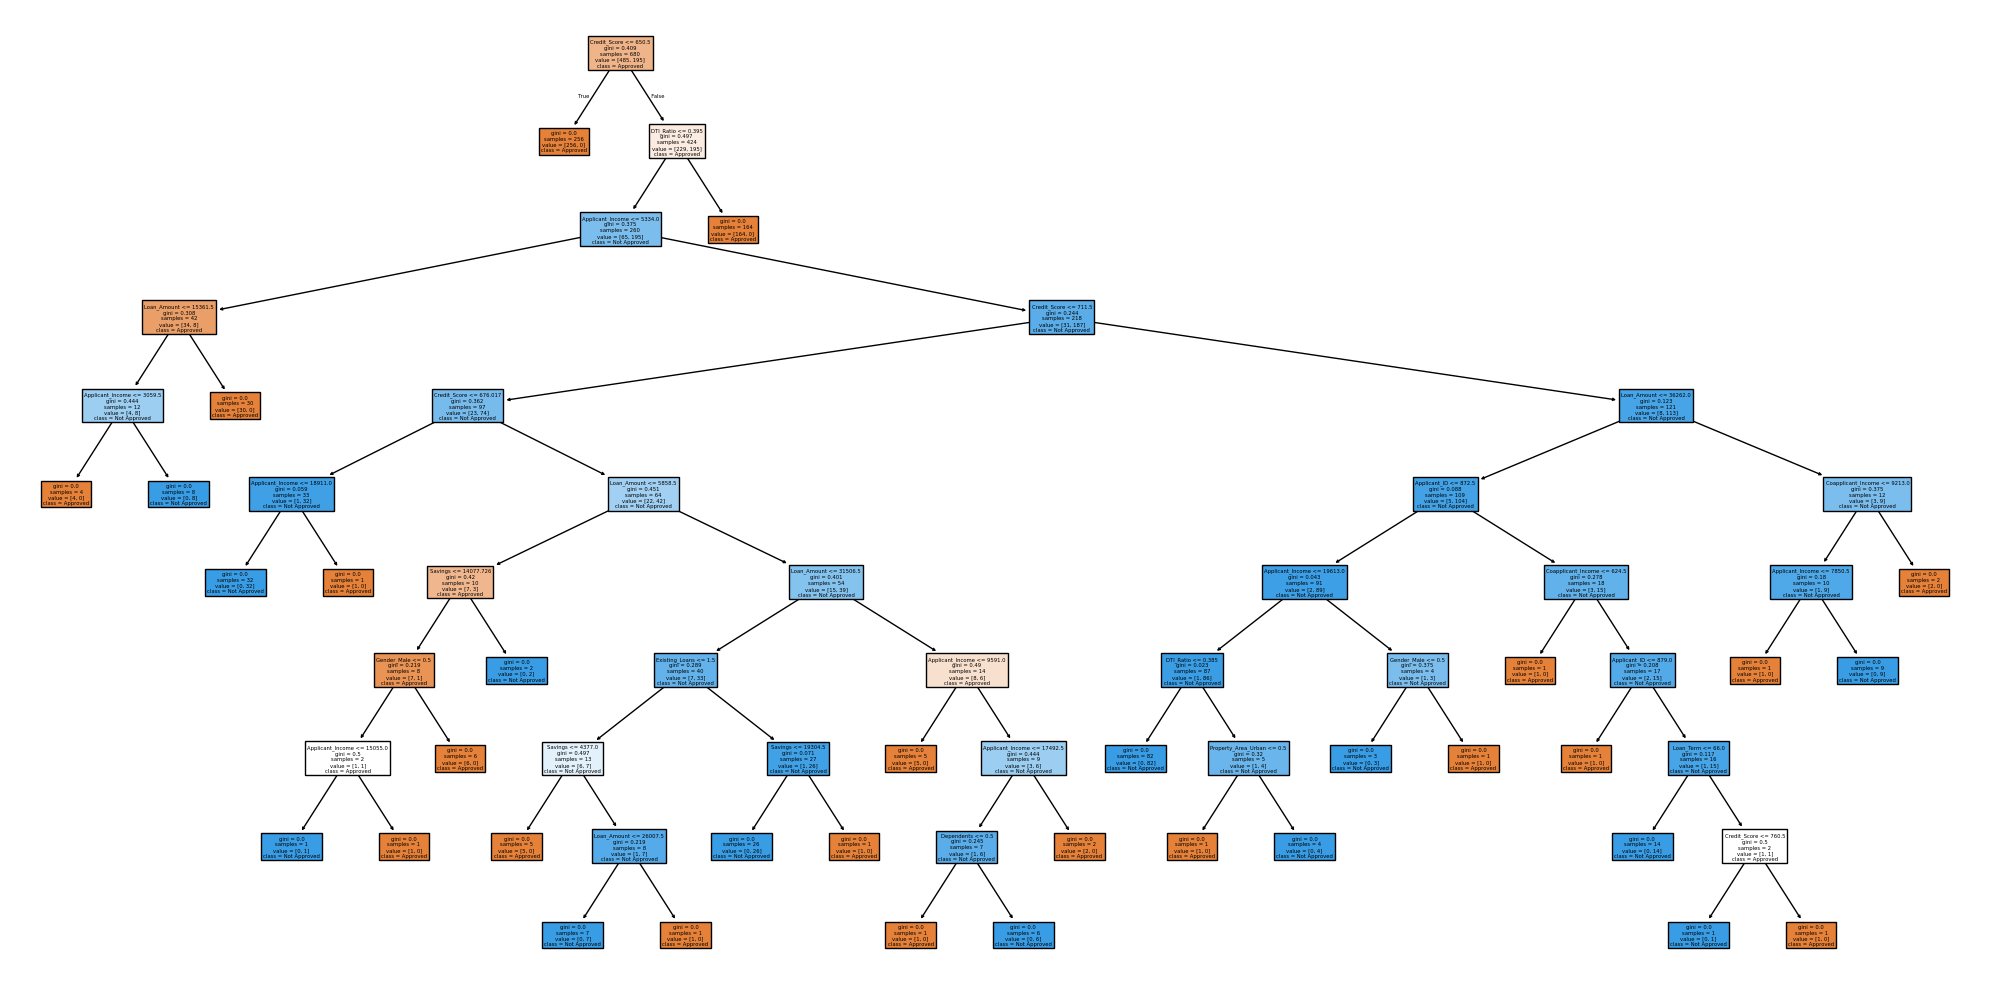

In [162]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(DT_model,
          filled=True,
          feature_names=X_train.columns,
          class_names=["Approved","Not Approved"],
         )
plt.tight_layout()
plt.show

plt.savefig("DT.png")

# Pre-prunning

In [163]:
from itertools import product
# Prepruning
max_depths=[2,3,4,5,6,7,8,9,10]
min_samples_splits=[2,3,4,5,6,7,8,9,10]

best_acc=0
best_depth=0
best_split=0

for depth,split in product(max_depths,min_samples_splits):
    DT=DecisionTreeClassifier(max_depth=depth,min_samples_split=split)
    DT.fit(X_train,y_train)
    y_pred=DT.predict(X_test)

    acc=DT.score(X_test,y_test)
    print(f"for depth={depth},splits={split},Accuracy={acc}")

    if acc > best_acc:
        best_acc=acc
        best_depth=depth
        best_split=split

print(f"\nBest: depth={best_depth}, split={best_split}, Accuracy={best_acc}")



for depth=2,splits=2,Accuracy=0.909375
for depth=2,splits=3,Accuracy=0.909375
for depth=2,splits=4,Accuracy=0.909375
for depth=2,splits=5,Accuracy=0.909375
for depth=2,splits=6,Accuracy=0.909375
for depth=2,splits=7,Accuracy=0.909375
for depth=2,splits=8,Accuracy=0.909375
for depth=2,splits=9,Accuracy=0.909375
for depth=2,splits=10,Accuracy=0.909375
for depth=3,splits=2,Accuracy=0.90625
for depth=3,splits=3,Accuracy=0.90625
for depth=3,splits=4,Accuracy=0.90625
for depth=3,splits=5,Accuracy=0.90625
for depth=3,splits=6,Accuracy=0.90625
for depth=3,splits=7,Accuracy=0.90625
for depth=3,splits=8,Accuracy=0.90625
for depth=3,splits=9,Accuracy=0.90625
for depth=3,splits=10,Accuracy=0.90625
for depth=4,splits=2,Accuracy=0.928125
for depth=4,splits=3,Accuracy=0.928125
for depth=4,splits=4,Accuracy=0.928125
for depth=4,splits=5,Accuracy=0.928125
for depth=4,splits=6,Accuracy=0.928125
for depth=4,splits=7,Accuracy=0.928125
for depth=4,splits=8,Accuracy=0.928125
for depth=4,splits=9,Accuracy=0.

# Post-prunning

In [164]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [165]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas
print(ccp_alphas)

[0.         0.00128676 0.00137868 0.00143827 0.00184029 0.00252101
 0.00257353 0.00264706 0.00264769 0.00283224 0.00285205 0.00336134
 0.00360294 0.00420168 0.00519924 0.00546099 0.00784314 0.01120448
 0.04612372 0.13283953]


In [166]:
best_ccp=0
best_acc=0

for alpha in ccp_alphas:
    DT = DecisionTreeClassifier(ccp_alpha=alpha)
    DT.fit(X_train, y_train)
    y_pred = DT.predict(X_test)

    acc=DT.score(X_test,y_test)
    print(f"for alpha={alpha},Accuracy={acc}")

    if acc > best_acc:
        best_acc=acc
        best_alpha=alpha

print(f"Best Alpha={best_alpha},Best Accuracy={best_acc}")



for alpha=0.0,Accuracy=0.903125
for alpha=0.001286764705882353,Accuracy=0.90625
for alpha=0.0013786764705882354,Accuracy=0.909375
for alpha=0.0014382676147382029,Accuracy=0.915625
for alpha=0.0018402923978342214,Accuracy=0.915625
for alpha=0.002521008403361345,Accuracy=0.90625
for alpha=0.002573529411764706,Accuracy=0.91875
for alpha=0.0026470588235294125,Accuracy=0.915625
for alpha=0.002647694379897687,Accuracy=0.9125
for alpha=0.0028322440087145957,Accuracy=0.915625
for alpha=0.0028520499108734385,Accuracy=0.91875
for alpha=0.0033613445378151254,Accuracy=0.91875
for alpha=0.0036029411764705887,Accuracy=0.909375
for alpha=0.0042016806722689065,Accuracy=0.896875
for alpha=0.005199239417989419,Accuracy=0.93125
for alpha=0.005460987896182053,Accuracy=0.93125
for alpha=0.00784313725490196,Accuracy=0.928125
for alpha=0.011204481792717089,Accuracy=0.90625
for alpha=0.04612372471924549,Accuracy=0.909375
for alpha=0.13283953287197234,Accuracy=0.678125
Best Alpha=0.005199239417989419,Best Accu

In [167]:
Final_tree=DecisionTreeClassifier(max_depth=5,ccp_alpha=0.005,min_samples_split=2)
Final_tree.fit(X_train,y_train)
y_pred=Final_tree.predict(X_test)

best_acc=Final_tree.score(X_test,y_test)
print(best_acc)

0.93125


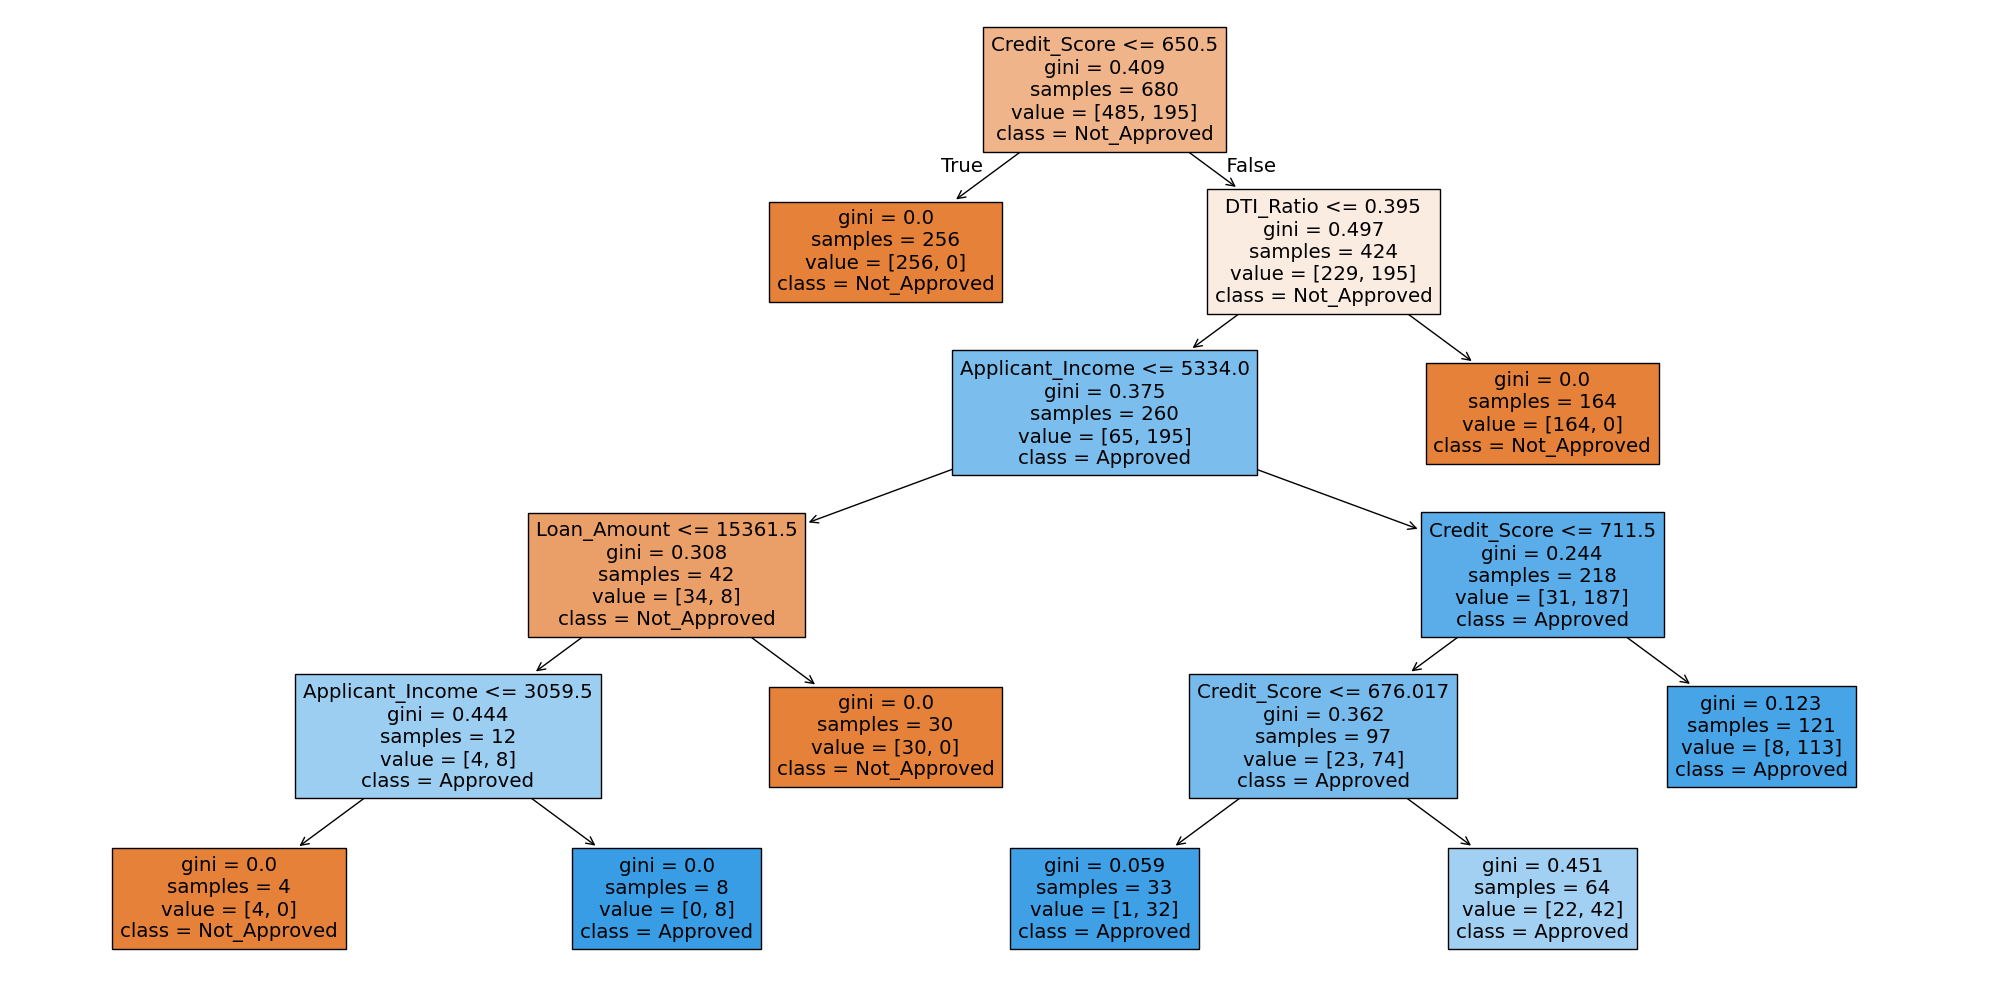

In [168]:
from sklearn import tree

plt.figure(figsize=(20,10))

plot_tree(
    Final_tree,
    class_names=["Not_Approved","Approved"],
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()

# Hyper Parameter Tunning by GridSearchCV

In [169]:
from sklearn.pipeline import Pipeline
algos={
    "LogisticRegression":
    (
        Pipeline(
            [("scaler",StandardScaler()),("clf",LogisticRegression(max_iter=1000))]
            ),
        {
            "clf__C":[0.01,0.1,1,10],
            "clf__penalty":["l1","l2"]
        }
    ),
    "NaiveBayes":
    (
        Pipeline(
            [("scaler",StandardScaler()),("clf",GaussianNB())]
            ),
        {
            "clf__var_smoothing":[1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
        }
    ),
    "KNN":
    (
        Pipeline(
            [("scaler",StandardScaler()),("clf",KNeighborsClassifier())]
            ),
        {
            "clf__n_neighbors":[3,5,7,9,11,13]
        }
    ),
    "DecisionTree":
    (
        Pipeline(
            [("scaler",StandardScaler()),("clf",DecisionTreeClassifier(random_state=42))]
            ),
        {
                "clf__max_depth":[2,3,5,8,9],
                "clf__ccp_alpha":[0.05,0.01,0.001,0.0012,0.010,0.2],
                "clf__min_samples_split":[2,3,4,5,6,7]
        }
    )
}



In [170]:
outcomes={}
best_algos={}
best_f1=0
best_model_name=None

for name,(Pipeline,param_grid) in algos.items():
    print(f"\nAfter Tuning {name}\n")

    grid=GridSearchCV(
        estimator=Pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="f1_weighted"
    )

    grid.fit(X_train,y_train)

    best_algo=grid.best_estimator_
    best_algos[name]=best_algo

    print(f"Best parameters:{grid.best_params_}")
    print(f"Best score:{grid.best_score_}")

    y_pred=grid.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)

    outcomes[name]={
        "Accuracy":grid.best_score_,
        "Precision":precision,
        "Recall":recall,
        "f1":f1
    }

    print(f"\nClassification Report:\n {classification_report(y_test,y_pred)}")
    print(f"\nConfusion Matrix:\n {confusion_matrix(y_test,y_pred)}")

    if f1 > best_f1:
        best_f1=f1
        best_algo_name=name

outcomes_df=pd.DataFrame(outcomes).T.round(2)
print("\nModel Comparison")
print(outcomes_df)

best_algo=best_algos[best_algo_name]
print(f"\nBest Algo: {best_algo_name}, Best F1: {best_f1:.2f}")




After Tuning LogisticRegression

Best parameters:{'clf__C': 0.1, 'clf__penalty': 'l2'}
Best score:0.8346374824995383

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90       217
           1       0.86      0.65      0.74       103

    accuracy                           0.85       320
   macro avg       0.86      0.80      0.82       320
weighted avg       0.85      0.85      0.85       320


Confusion Matrix:
 [[206  11]
 [ 36  67]]

After Tuning NaiveBayes

Best parameters:{'clf__var_smoothing': 1e-09}
Best score:0.8524809472704182

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.94      0.91       217
           1       0.86      0.71      0.78       103

    accuracy                           0.87       320
   macro avg       0.87      0.83      0.84       320
weighted avg       0.87      0.87      0.87       320


Confusion Matrix:
 [[205  12]
 [

# Best Tree After Hyper Parameter Tunning

Decision Tree Best Params after Tuning: Max_depth= 5| Min_splits= 2| Best_ccp_alpha= 0.001


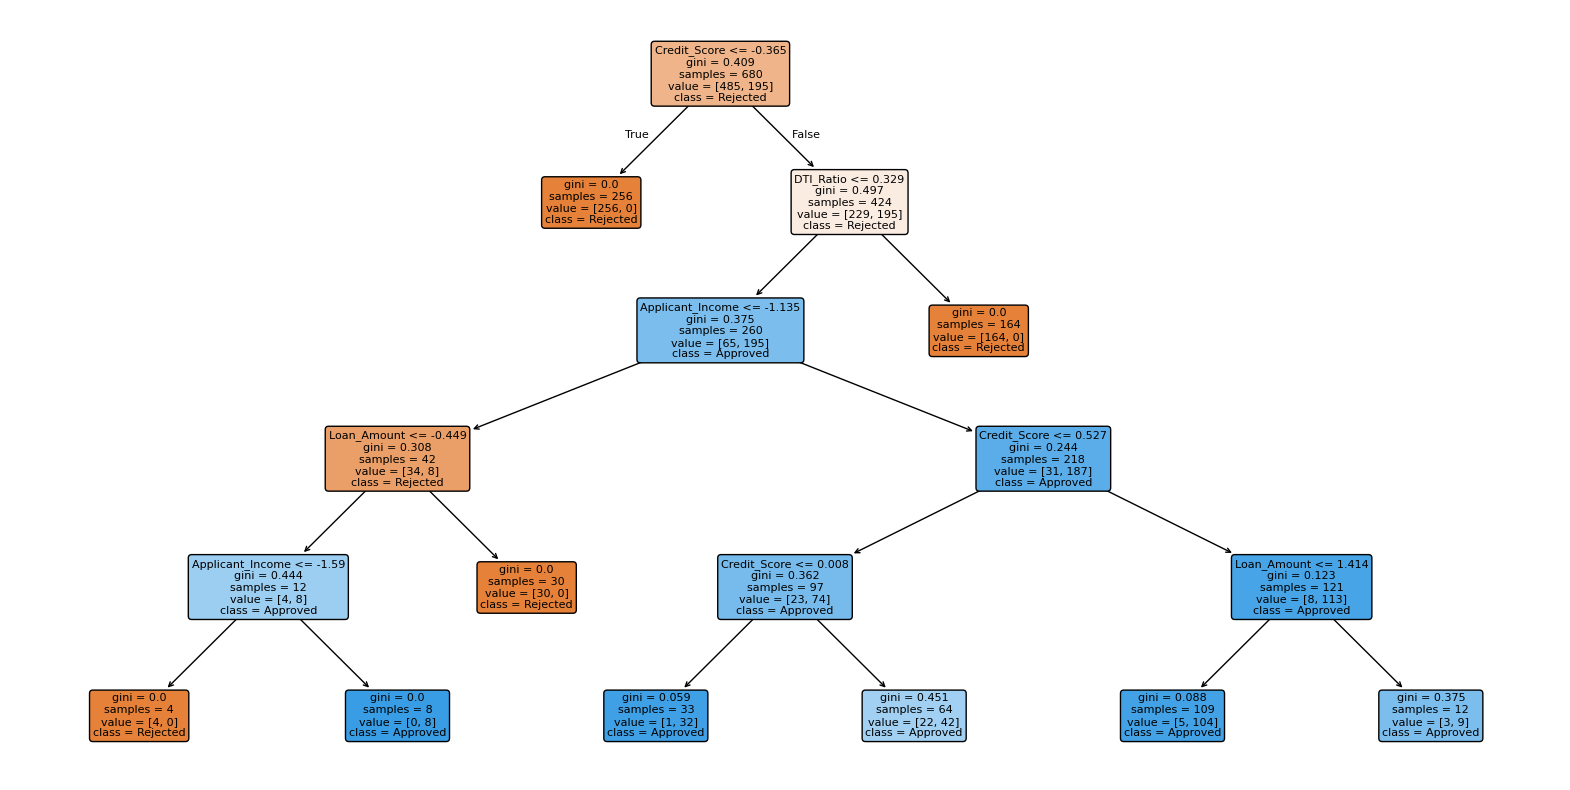

In [171]:
dt_classifier = best_algo.named_steps["clf"]   # extract the DecisionTreeClassifier step

print(f"Decision Tree Best Params after Tuning: Max_depth= {dt_classifier.max_depth}| Min_splits= {dt_classifier.min_samples_split}| Best_ccp_alpha= {dt_classifier.ccp_alpha}")

plt.figure(figsize=(20, 10))
plot_tree(
    dt_classifier,
    feature_names=X.columns,      # or your feature column names
    class_names=["Rejected", "Approved"],  # adjust to match your target labels
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()


# Evaluation Metric Plot

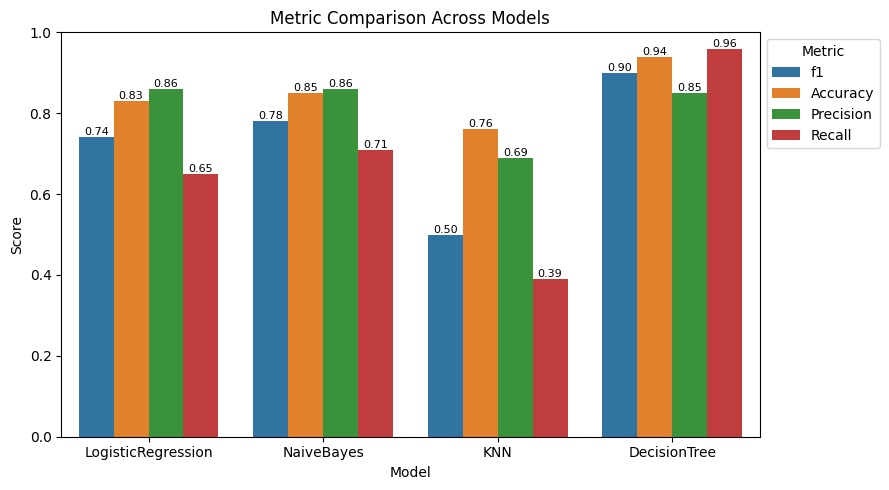

In [189]:
plt.figure(figsize=(9, 5))

melted = outcomes_df[["f1", "Accuracy", "Precision", "Recall"]].reset_index().melt(id_vars="index")
ax = sns.barplot(data=melted, x="index", y="value", hue="variable", dodge=True)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.title("Metric Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Metric", bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()